In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('ToyotaCorolla.csv', encoding = 'latin1')
print('Размер датасета: ', df.shape)
df.head()

Размер датасета:  (1436, 39)


,ï»¿Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


In [4]:
df.info()   #выводим основную информацию о датасете
df.describe(include = 'all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ï»¿Id              1436 non-null   int64 
 1   Model              1436 non-null   object
 2   Price              1436 non-null   int64 
 3   Age_08_04          1436 non-null   int64 
 4   Mfg_Month          1436 non-null   int64 
 5   Mfg_Year           1436 non-null   int64 
 6   KM                 1436 non-null   int64 
 7   Fuel_Type          1436 non-null   object
 8   HP                 1436 non-null   int64 
 9   Met_Color          1436 non-null   int64 
 10  Color              1436 non-null   object
 11  Automatic          1436 non-null   int64 
 12  CC                 1436 non-null   int64 
 13  Doors              1436 non-null   int64 
 14  Cylinders          1436 non-null   int64 
 15  Gears              1436 non-null   int64 
 16  Quarterly_Tax      1436 non-null   int64 


,ï»¿Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.000000,1436,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436,1436.000000,1436.000000,...,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
unique,NaN,319,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,TOYOTA Corolla 1.6 16V HATCHB LINEA TERRA 2/3-...,NaN,NaN,NaN,NaN,NaN,Petrol,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,109,NaN,NaN,NaN,NaN,NaN,1264,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,721.555014,NaN,10730.824513,55.947075,5.548747,1999.625348,68533.259749,NaN,101.502089,0.674791,...,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
std,416.476890,NaN,3626.964585,18.599988,3.354085,1.540722,37506.448872,NaN,14.981080,0.468616,...,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
min,1.000000,NaN,4350.000000,1.000000,1.000000,1998.000000,1.000000,NaN,69.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,NaN,8450.000000,44.000000,3.000000,1998.000000,43000.000000,NaN,90.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,721.500000,NaN,9900.000000,61.000000,5.000000,1999.000000,63389.500000,NaN,110.000000,1.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1081.250000,NaN,11950.000000,70.000000,8.000000,2001.000000,87020.750000,NaN,110.000000,1.000000,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000



информация о данных
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ï»¿Id              1436 non-null   int64 
 1   Model              1436 non-null   object
 2   Price              1436 non-null   int64 
 3   Age_08_04          1436 non-null   int64 
 4   Mfg_Month          1436 non-null   int64 
 5   Mfg_Year           1436 non-null   int64 
 6   KM                 1436 non-null   int64 
 7   Fuel_Type          1436 non-null   object
 8   HP                 1436 non-null   int64 
 9   Met_Color          1436 non-null   int64 
 10  Color              1436 non-null   object
 11  Automatic          1436 non-null   int64 
 12  CC                 1436 non-null   int64 
 13  Doors              1436 non-null   int64 
 14  Cylinders          1436 non-null   int64 
 15  Gears              1436 non-null   int64 
 16  Quarterly_Tax      14

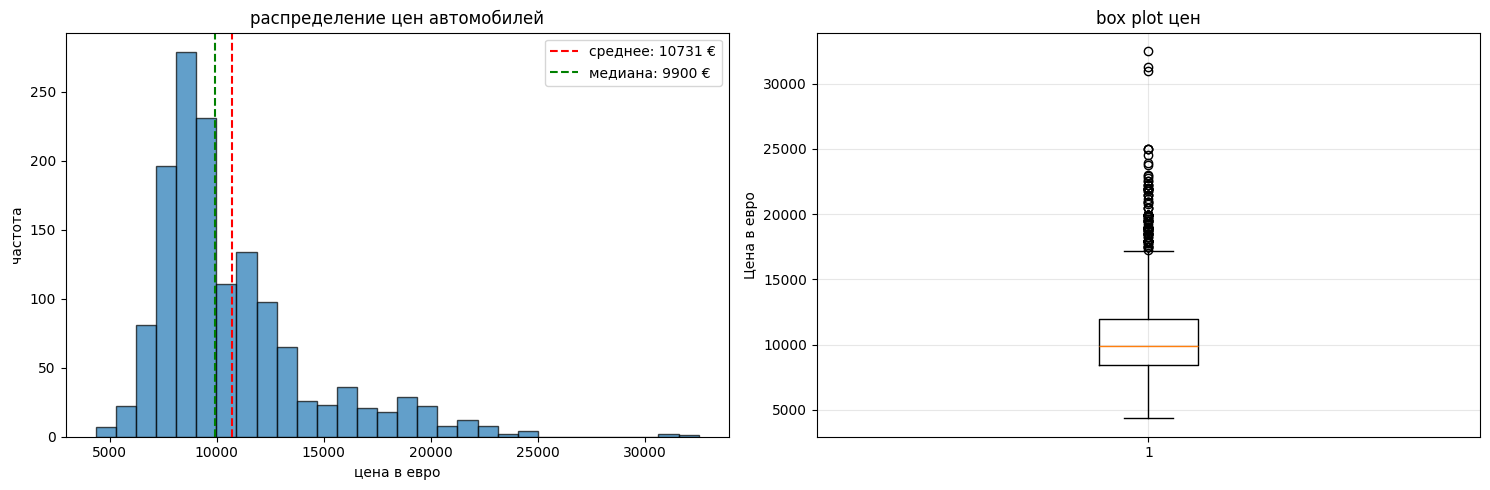


корелляционный анализ
корреляция признаков с ценой:
Price                1.000000
Mfg_Year             0.885159
Boardcomputer        0.601292
Automatic_airco      0.588262
Weight               0.581198
CD_Player            0.481374
Airco                0.429259
Powered_Windows      0.356518
Central_Lock         0.343458
HP                   0.314990
ABS                  0.306138
Airbag_2             0.248974
Mistlamps            0.222083
Quarterly_Tax        0.219197
Mfr_Guarantee        0.197802
Doors                0.185326
Sport_Model          0.164121
Guarantee_Period     0.146627
CC                   0.126389
Met_Color            0.108905
Metallic_Rim         0.108564
Backseat_Divider     0.102569
Airbag_1             0.093588
Power_Steering       0.064275
Gears                0.063104
Parking_Assistant    0.044375
Automatic            0.033081
BOVAG_Guarantee      0.028133
Mfg_Month           -0.018138
Radio               -0.041887
Radio_cassette      -0.043179
Tow_Bar          

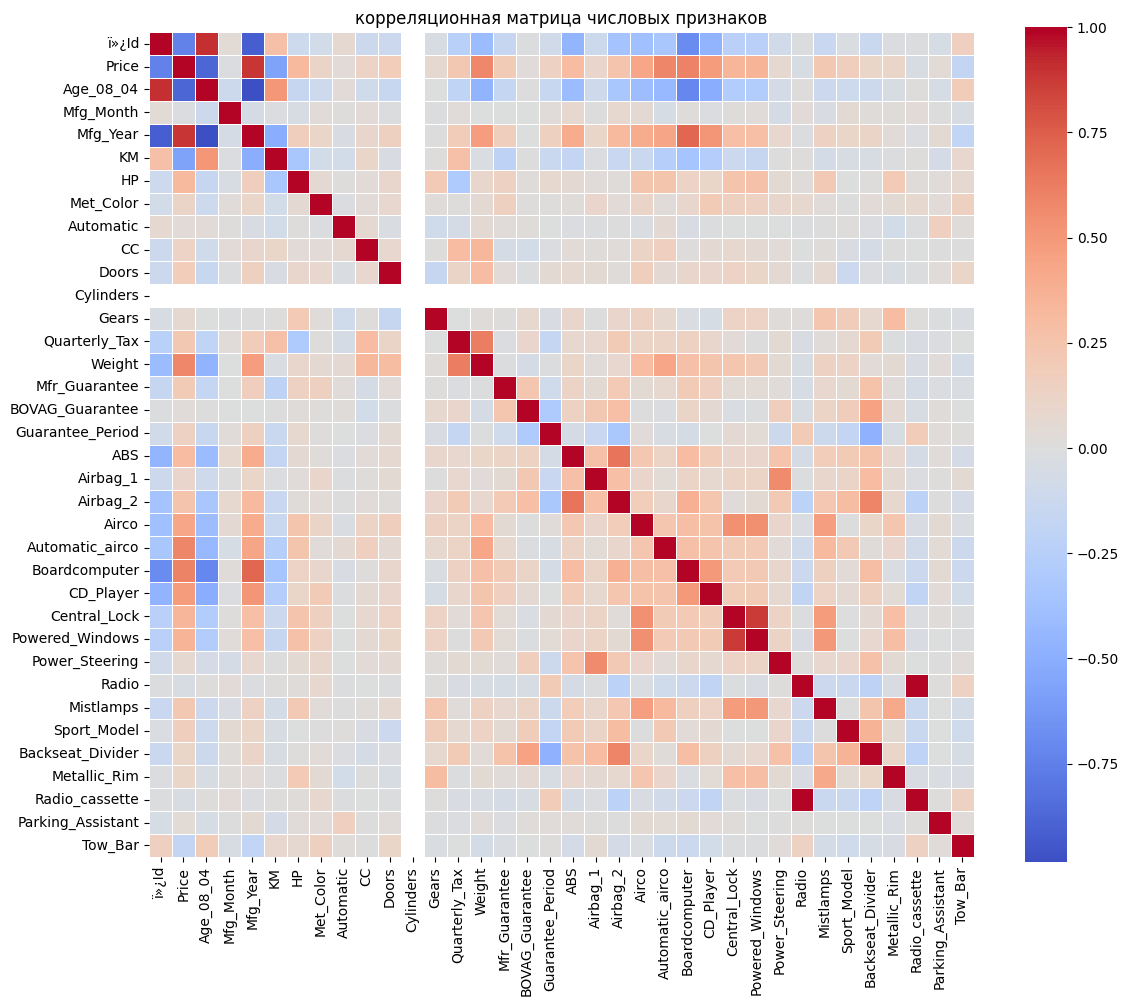

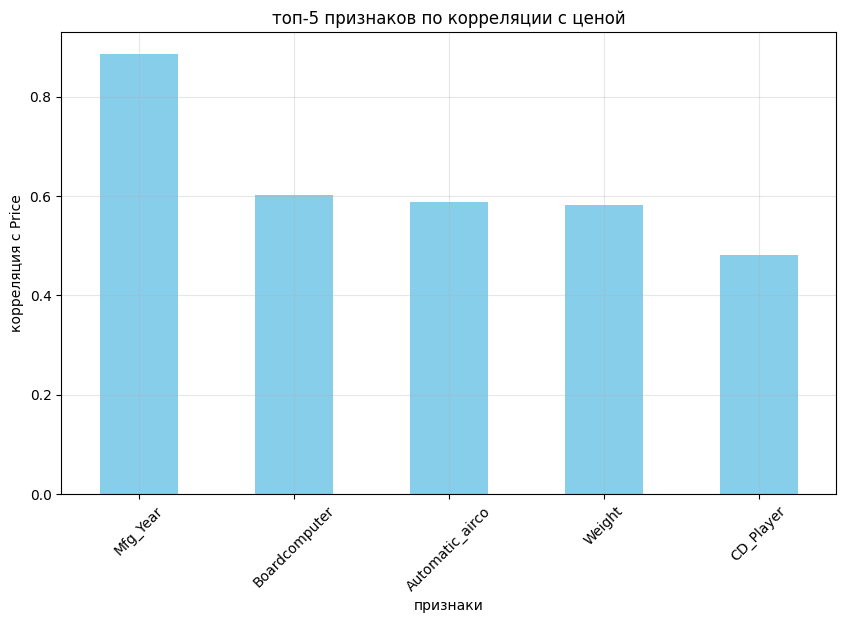

In [5]:



print("\nинформация о данных")
print(df.info())


print("\n проверка пропусков")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Пропусков': missing_data,
    'Процент': missing_percent
})
print(missing_df[missing_df['Пропусков'] > 0])



print(df.describe())


print("\nанализ целевой переменной")
print(f"Средняя цена: {df['Price'].mean():.2f} €")
print(f"Медианная цена: {df['Price'].median():.2f} €")
print(f"Минимальная цена: {df['Price'].min():.2f} €")
print(f"Максимальная цена: {df['Price'].max():.2f} €")
print(f"Стандартное отклонение: {df['Price'].std():.2f} €")


fig, axes = plt.subplots(1, 2, figsize=(15, 5)) #визуально показываем распределение цены

#построим гистограмму
axes[0].hist(df['Price'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('цена в евро')
axes[0].set_ylabel('частота')
axes[0].set_title('распределение цен автомобилей')
axes[0].axvline(df['Price'].mean(), color='red', linestyle='--', label=f'среднее: {df["Price"].mean():.0f} €')
axes[0].axvline(df['Price'].median(), color='green', linestyle='--', label=f'медиана: {df["Price"].median():.0f} €')
axes[0].legend()


axes[1].boxplot(df['Price'])
axes[1].set_ylabel('Цена в евро')
axes[1].set_title('box plot цен')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



print("\nкорелляционный анализ")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()


price_corr = corr_matrix['Price'].sort_values(ascending=False)
print("корреляция признаков с ценой:")
print(price_corr)


plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()


top_features = price_corr[1:6]
plt.figure(figsize=(10, 6))
top_features.plot(kind='bar', color='skyblue')
plt.title('топ-5 признаков по корреляции с ценой')
plt.xlabel('признаки')
plt.ylabel('корреляция с Price')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()


#я провёл первичный анализ данных, проверил пропуски, посмотрел статистику, проанализировал корреляцию между признаками
#проведя EDA я понял, что данные содержат как числовые, так и категориальные признаки; некоторые признаки сильно
#коррелируют с ценой(возраст авто, пробег); имеются также неинформативные признаки, например, id

In [16]:



df_processed = df.copy() #создаём копию данных для работы

#удаление неинформативных признаков
cols_to_drop = ['Id']  # удаляем идентификатор, если он есть
if 'Id' in df_processed.columns:
    df_processed.drop('Id', axis=1, inplace=True)


#создание новых признаков
# признак "возраст автомобиля" (если есть год выпуска)
if 'Mfg_Year' in df_processed.columns:
    current_year = 2026
    df_processed['Car_Age'] = current_year - df_processed['Mfg_Year']


# признак "интенсивность использования" (пробег / возраст)
if 'KM' in df_processed.columns and 'Car_Age' in df_processed.columns:
    df_processed['KM_per_Year'] = df_processed['KM'] / (df_processed['Car_Age'] + 1)




#находим целевую переменную
y = df_processed['Price']

#находим признаки
X = df_processed.drop('Price', axis=1)

#числовые признаки
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"Числовых признаков: {len(numeric_features)}")
print(f"Числовые признаки: {numeric_features[:10]}")

#категориальные признаки
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
print(f"\nКатегориальных признаков: {len(categorical_features)}")
print(f"Категориальные признаки: {categorical_features}")


#я провёл анализ и посмотрел, какие признаки важны, а какие нет
#создал такие признаки как "возраст автомобиля", "интенсивность использования", так как мне показалось, что именно они в будущем помогут правильно обучить модель
#также удалил признак "Id", потому что он бесполезен


Числовых признаков: 37
Числовые признаки: ['ï»¿Id', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM', 'HP', 'Met_Color', 'Automatic', 'CC', 'Doors']

Категориальных признаков: 3
Категориальные признаки: ['Model', 'Fuel_Type', 'Color']


In [18]:


#разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"размер обучающей выборки (X_train): {X_train.shape}")
print(f"размер тестовой выборки (X_test): {X_test.shape}")
print(f"размер обучающей выборки (y_train): {y_train.shape}")
print(f"размер тестовой выборки (y_test): {y_test.shape}")
print(f"\nсоотношение: {len(X_train)/len(X)*100:.1f}% / {len(X_test)/len(X)*100:.1f}%")

#проверка распределения целевой переменной в выборках
print(f"средняя цена в обучающей выборке: {y_train.mean():.2f} €")
print(f"средняя цена в тестовой выборке: {y_test.mean():.2f} €")

#использовал функцию train_test_split с 20% данных для теста и random_state = 42
#разделение необходимо для объективной оценки качества модели, сначала обучаем модель на одной части данных, а затем на другой, чтобы оценить универсальность модели

размер обучающей выборки (X_train): (1148, 40)
размер тестовой выборки (X_test): (288, 40)
размер обучающей выборки (y_train): (1148,)
размер тестовой выборки (y_test): (288,)

соотношение: 79.9% / 20.1%
средняя цена в обучающей выборке: 10754.40 €
средняя цена в тестовой выборке: 10636.87 €


время обучения: 0.0668 секунд
время обучения: 0.0587 секунд
время обучения: 2.7857 секунд
модель обучена
             модель  время (сек)
0  LinearRegression     0.066800
1             Ridge     0.058678
2             Lasso     2.785730


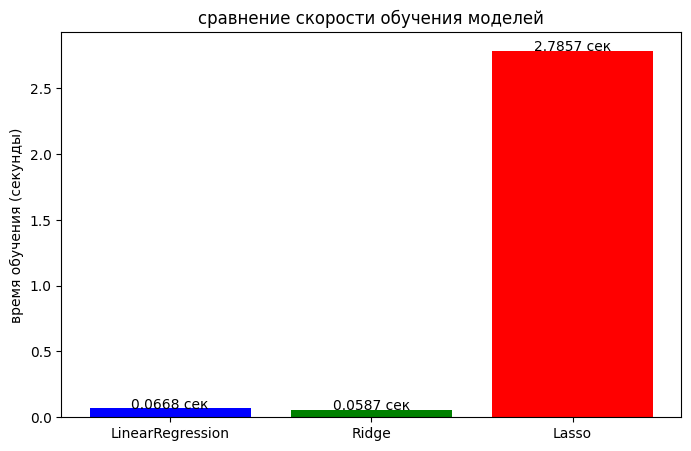

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])


import time
start_time = time.time()
lr_pipeline.fit(X_train, y_train)
lr_time = time.time() - start_time

y_pred_lr = lr_pipeline.predict(X_test)
print(f"время обучения: {lr_time:.4f} секунд")

ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

start_time = time.time()
ridge_pipeline.fit(X_train, y_train)
ridge_time = time.time() - start_time

y_pred_ridge = ridge_pipeline.predict(X_test)
print(f"время обучения: {ridge_time:.4f} секунд")


lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=0.1, max_iter=10000))
])

start_time = time.time()
lasso_pipeline.fit(X_train, y_train)
lasso_time = time.time() - start_time

y_pred_lasso = lasso_pipeline.predict(X_test)
print(f"время обучения: {lasso_time:.4f} секунд")
print("модель обучена")

speed_df = pd.DataFrame({
    'модель': ['LinearRegression', 'Ridge', 'Lasso'],
    'время (сек)': [lr_time, ridge_time, lasso_time]
})
print(speed_df)

plt.figure(figsize=(8, 5))
plt.bar(speed_df['модель'], speed_df['время (сек)'], color=['blue', 'green', 'red'])
plt.ylabel('время обучения (секунды)')
plt.title('сравнение скорости обучения моделей')
for i, v in enumerate(speed_df['время (сек)']):
    plt.text(i, v + 0.001, f'{v:.4f} сек', ha='center')
plt.show()

#обучал модели через пайплайны, которые сначана применяли предобработку, а затем уже обучали модель
#как видим, обычная линейная модель и ridge обучаются быстро и почти одинаково по времени, а вот lasso-модель у меня обучалась сильно дольше


LinearRegression (test):
  MAE  = 1221.17
  R²   = 0.5218

Ridge (test):
  MAE  = 792.75
  R²   = 0.8969

Lasso (test):
  MAE  = 859.51
  R²   = 0.8196

LinearRegression (train):
  MAE  = 503.21
  R²   = 0.9613

Ridge (train):
  MAE  = 607.64
  R²   = 0.9522

Lasso (train):
  MAE  = 524.96
  R²   = 0.9608
             модель  R²_train  R²_test   MAE_test  разница R²
0  LinearRegression    0.9613   0.5218  1221.1729      0.4395
1             Ridge    0.9522   0.8969   792.7544      0.0553
2             Lasso    0.9608   0.8196   859.5063      0.1411


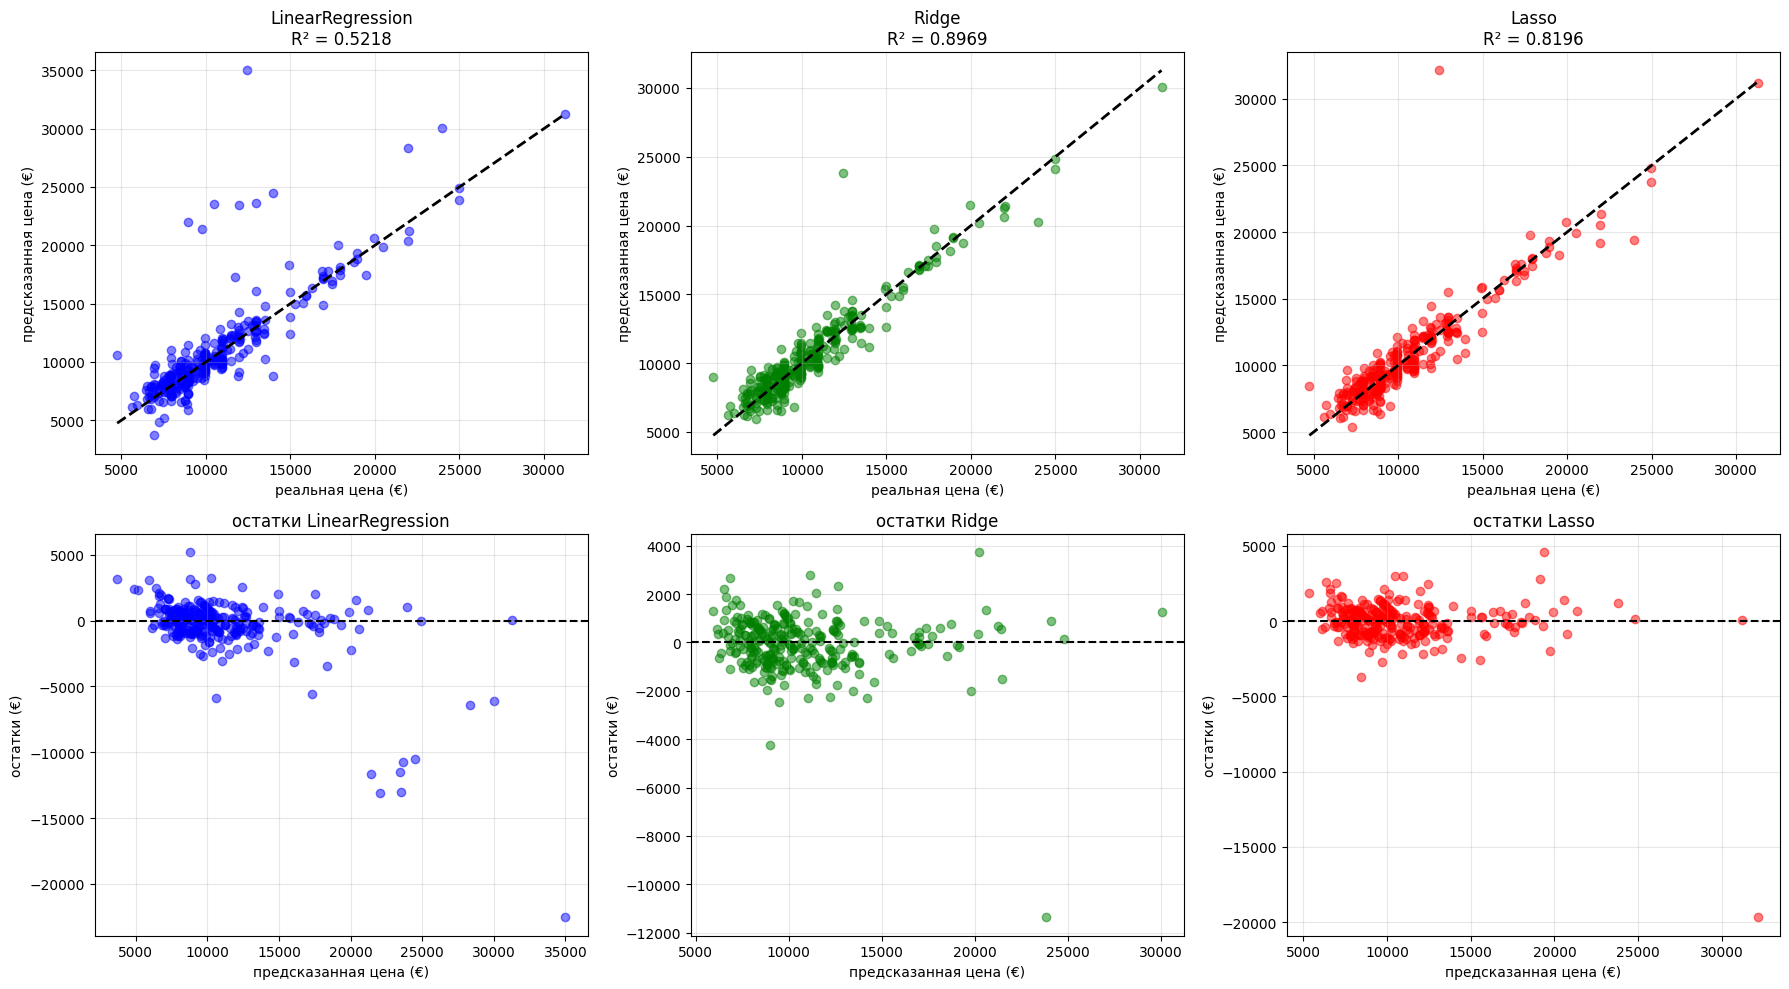

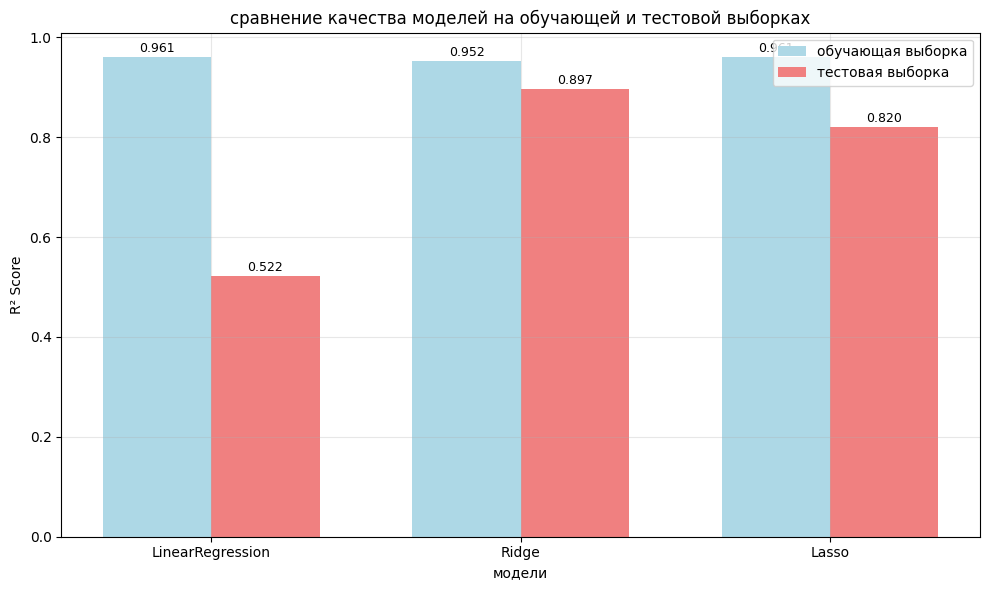


 лучшая модель: Ridge
R² на тесте: 0.8969
MAE на тесте: 792.75 €


In [26]:
def calculate_metrics(y_true, y_pred, model_name, dataset_type=""):


    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)




    metrics = {
        'MAE': mae,
        'MSE': mse,
        'R2': r2

    }

    print(f"\n{model_name} {dataset_type}:")
    print(f"  MAE  = {mae:.2f}")
    print(f"  R²   = {r2:.4f}")


    return metrics

results_test = {}
results_test['LinearRegression'] = calculate_metrics(y_test, y_pred_lr, 'LinearRegression', '(test)')
results_test['Ridge'] = calculate_metrics(y_test, y_pred_ridge, 'Ridge', '(test)')
results_test['Lasso'] = calculate_metrics(y_test, y_pred_lasso, 'Lasso', '(test)')


y_train_pred_lr = lr_pipeline.predict(X_train)
y_train_pred_ridge = ridge_pipeline.predict(X_train)
y_train_pred_lasso = lasso_pipeline.predict(X_train)

results_train = {}
results_train['LinearRegression'] = calculate_metrics(y_train, y_train_pred_lr, 'LinearRegression', '(train)')
results_train['Ridge'] = calculate_metrics(y_train, y_train_pred_ridge, 'Ridge', '(train)')
results_train['Lasso'] = calculate_metrics(y_train, y_train_pred_lasso, 'Lasso', '(train)')



summary = []
for model in ['LinearRegression', 'Ridge', 'Lasso']:
    summary.append({
        'модель': model,
        'R²_train': results_train[model]['R2'],
        'R²_test': results_test[model]['R2'],
        'MAE_test': results_test[model]['MAE'],
        'разница R²': results_train[model]['R2'] - results_test[model]['R2']
    })

summary_df = pd.DataFrame(summary)
print(summary_df.round(4))


fig, axes = plt.subplots(2, 3, figsize=(18, 10))


models = ['LinearRegression', 'Ridge', 'Lasso']
predictions = [y_pred_lr, y_pred_ridge, y_pred_lasso]
colors = ['blue', 'green', 'red']

for i, (model, pred, color) in enumerate(zip(models, predictions, colors)):

    axes[0, i].scatter(y_test, pred, alpha=0.5, color=color)
    axes[0, i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    axes[0, i].set_xlabel('реальная цена (€)')
    axes[0, i].set_ylabel('предсказанная цена (€)')
    axes[0, i].set_title(f'{model}\nR² = {results_test[model]["R2"]:.4f}')
    axes[0, i].grid(True, alpha=0.3)


    residuals = y_test - pred
    axes[1, i].scatter(pred, residuals, alpha=0.5, color=color)
    axes[1, i].axhline(y=0, color='k', linestyle='--')
    axes[1, i].set_xlabel('предсказанная цена (€)')
    axes[1, i].set_ylabel('остатки (€)')
    axes[1, i].set_title(f'остатки {model}')
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
x = np.arange(len(models))
width = 0.35

train_scores = [results_train[m]['R2'] for m in models]
test_scores = [results_test[m]['R2'] for m in models]

plt.bar(x - width/2, train_scores, width, label='обучающая выборка', color='lightblue')
plt.bar(x + width/2, test_scores, width, label='тестовая выборка', color='lightcoral')

plt.xlabel('модели')
plt.ylabel('R² Score')
plt.title('сравнение качества моделей на обучающей и тестовой выборках')
plt.xticks(x, models)
plt.legend()
plt.grid(True, alpha=0.3)

for i, v in enumerate(train_scores):
    plt.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
for i, v in enumerate(test_scores):
    plt.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

best_model_idx = np.argmax([results_test[m]['R2'] for m in models])
best_model = models[best_model_idx]
best_r2 = results_test[best_model]['R2']

print(f"\n лучшая модель: {best_model}")
print(f"R² на тесте: {best_r2:.4f}")
print(f"MAE на тесте: {results_test[best_model]['MAE']:.2f} €")
#использовал метрики r2, mae, так как это основные метрики для анализа обучение моделей
#метрики посчитаны на тестовой выборке в 20% от основных данных
#лучше всего справилась модель ridge
#результаты с квадратичной метрикой больше 0,8 обычно считаются хорошими, поэтому можно сказать, что получилась хорошая модель
#нужно сравнить результаты на обучающей и тестовой выборке, если разница не более 0,1 , значит сильное обучение отсутствует